# Supplementary Notebook S1. Characterising EpiLink

This notebook is designed as a manuscript-quality supplementary analysis for a PLOS Computational Biology submission introducing `epilink`. It provides a compact but reproducible characterisation of what EpiLink scores represent, how they behave across clinically relevant observation space, and how sensitive they are to key modelling choices.

Scientific aims:

- characterise the scale and interpretation of EpiLink compatibility scores
- show how timing and genetic distance jointly shape support for recent-transmission scenarios
- illustrate how target definition, hidden-depth allowance, and mutation-process assumptions change interpretation
- assess Monte Carlo stability and scenario recovery under simulated data
- demonstrate sensitivity to mutation-rate and natural-history assumptions

Recommended use in the supplement:

- treat each numbered section below as a figure-generating analysis block
- cite the notebook as a reproducible companion to the manuscript text rather than as a replacement for formal methods
- keep the seeded defaults if exact regeneration of the displayed analyses matters

The longest-running sections are the Monte Carlo stability, scenario-recovery, and sensitivity analyses near the end of the notebook.


## Reproducibility and notebook setup

Run the next code cell once. It imports the plotting libraries, defines the helper functions used throughout the supplement, and fixes notebook-wide defaults. The following short cell then records the default parameterisation and environment metadata used for this supplementary analysis.


In [1]:
from __future__ import annotations

from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import ListedColormap

from epilink import EpiLink, InfectiousnessToTransmission, NaturalHistoryParameters

sns.set_theme(context='notebook', style='white')
plt.rcParams.update(
    {
        'font.size': 10,
        'axes.titlesize': 11,
        'axes.labelsize': 10,
        'legend.fontsize': 9,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'figure.titlesize': 15,
        'figure.dpi': 120,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': False,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'savefig.facecolor': 'white',
    }
)

SEED = 2026
MAXIMUM_DEPTH = 2
MC_SAMPLES = 6_000
DEFAULT_TARGET = ['ad(0)', 'ca(0,0)']
DEFAULT_OBSERVATION = {'time': 3.0, 'genetic': 2.0}
SURFACE_TIME_GRID = np.linspace(-18, 18, 181)
SURFACE_GENETIC_GRID = np.linspace(0, 14, 141)
SCENARIOS = ['ad(0)', 'ca(0,0)', 'ad(1)', 'ca(0,1)', 'ca(1,0)', 'ca(1,1)']
SCENARIO_LABELS = {
    'ad(0)': 'AD(0)',
    'ca(0,0)': 'CA(0,0)',
    'ad(1)': 'AD(1)',
    'ca(0,1)': 'CA(0,1)',
    'ca(1,0)': 'CA(1,0)',
    'ca(1,1)': 'CA(1,1)',
}
WINNER_SCENARIOS = SCENARIOS.copy()
WINNER_LABELS = [SCENARIO_LABELS[label] for label in WINNER_SCENARIOS]
MUTATION_MODELS = {
    'Deterministic': 'deterministic',
    'Stochastic': 'stochastic',
}
TOY_CASES = [
    {'label': 'Small gap\nlow distance', 'time': 1.0, 'genetic': 0.0},
    {'label': 'Large gap\nlow distance', 'time': 12.0, 'genetic': 0.0},
    {'label': 'Small gap\nhigh distance', 'time': 1.0, 'genetic': 8.0},
    {'label': 'Large gap\nhigh distance', 'time': 12.0, 'genetic': 8.0},
]
TARGET_COMPARISONS = [
    ('Direct only', ['ad(0)']),
    ('Shared ancestor only', ['ca(0,0)']),
    ('Recent transmission', ['ad(0)', 'ca(0,0)']),
    ('Allow one hidden step', ['ad(0)', 'ad(1)', 'ca(0,0)']),
]
SCENARIO_COLORS = {
    label: color
    for label, color in zip(
        SCENARIOS,
        sns.color_palette('colorblind', n_colors=len(SCENARIOS)),
        strict=True,
    )
}
UNKNOWN_SCENARIO_COLOR = '#9e9e9e'


def make_model(
    *,
    mutation_process: str = 'stochastic',
    seed: int = SEED,
    substitution_rate: float | None = None,
    parameters: NaturalHistoryParameters | None = None,
    maximum_depth: int = MAXIMUM_DEPTH,
    mc_samples: int = MC_SAMPLES,
    target: str | list[str] = 'ad(0)',
) -> EpiLink:
    resolved_parameters = NaturalHistoryParameters() if parameters is None else parameters
    if substitution_rate is not None:
        resolved_parameters = replace(resolved_parameters, substitution_rate=float(substitution_rate))
    profile = InfectiousnessToTransmission(parameters=resolved_parameters, rng_seed=seed)
    return EpiLink(
        transmission_profile=profile,
        maximum_depth=maximum_depth,
        mc_samples=mc_samples,
        target=target,
        mutation_process=mutation_process,
    )


def display_label(label: str) -> str:
    return SCENARIO_LABELS.get(label, label.upper())


def display_color(label: str):
    return SCENARIO_COLORS.get(label, UNKNOWN_SCENARIO_COLOR)


def format_target_labels(labels: list[str] | tuple[str, ...]) -> str:
    return ' + '.join(display_label(label) for label in labels)


def compatibility_curve_from_draws(observed_values: np.ndarray, simulated_draws: np.ndarray) -> np.ndarray:
    sorted_draws = np.sort(np.asarray(simulated_draws, dtype=float))
    percentiles = np.searchsorted(sorted_draws, observed_values, side='right') / sorted_draws.size
    return 1.0 - 2.0 * np.abs(percentiles - 0.5)


def summarize_pair(
    model: EpiLink,
    sample_time_difference: float,
    genetic_distance: float,
    target: str | list[str] | None = None,
) -> dict[str, object]:
    resolved_target = model.target_labels if target is None else target
    result = model.score_pair(
        sample_time_difference=float(sample_time_difference),
        genetic_distance=float(genetic_distance),
    )
    if target is None:
        target_score = float(result['target_compatibility'])
    else:
        target_score = float(model.score_target(sample_time_difference, genetic_distance, target=resolved_target))
    winner = max(
        result['scenario_scores'],
        key=lambda label: result['scenario_scores'][label]['compatibility'],
    )
    return {
        'time': float(sample_time_difference),
        'genetic': float(genetic_distance),
        'score': target_score,
        'winner': winner,
        'winner_display': display_label(winner),
        'target_display': format_target_labels(model.target_labels if target is None else tuple(resolved_target)),
    }


def select_representative_pairs(
    model: EpiLink,
    *,
    target: list[str] | tuple[str, ...] = tuple(DEFAULT_TARGET),
    desired_scores: tuple[float, ...] = (0.15, 0.5, 0.85),
    labels: tuple[str, ...] = ('Low', 'Medium', 'High'),
) -> list[dict[str, object]]:
    time_grid = np.arange(0, 15, dtype=float)
    genetic_grid = np.arange(0, 13, dtype=float)
    score_grid = np.asarray(model.score_target(time_grid[None, :], genetic_grid[:, None], target=target), dtype=float)
    used = np.zeros_like(score_grid, dtype=bool)
    selected: list[dict[str, object]] = []

    for label, desired_score in zip(labels, desired_scores, strict=True):
        distance = np.abs(score_grid - desired_score)
        distance[used] = np.inf
        row, col = np.unravel_index(np.argmin(distance), distance.shape)
        used[row, col] = True
        summary = summarize_pair(
            model,
            sample_time_difference=float(time_grid[col]),
            genetic_distance=float(genetic_grid[row]),
            target=list(target),
        )
        summary['label'] = label
        selected.append(summary)

    return selected


def top_scenario_for_grid(
    model: EpiLink,
    time_grid: np.ndarray,
    genetic_grid: np.ndarray,
    scenario_labels: list[str],
) -> np.ndarray:
    winner_index = np.zeros((genetic_grid.size, time_grid.size), dtype=int)
    winner_score = np.full((genetic_grid.size, time_grid.size), -np.inf, dtype=float)
    for idx, label in enumerate(scenario_labels):
        score = model.score_target(time_grid[None, :], genetic_grid[:, None], target=label)
        update_mask = score > winner_score
        winner_index[update_mask] = idx
        winner_score[update_mask] = score[update_mask]
    return winner_index


def best_score_for_grid(
    model: EpiLink,
    time_grid: np.ndarray,
    genetic_grid: np.ndarray,
    scenario_labels: list[str],
) -> np.ndarray:
    score_stack = np.stack(
        [np.asarray(model.score_target(time_grid[None, :], genetic_grid[:, None], target=label), dtype=float) for label in scenario_labels],
        axis=0,
    )
    return score_stack.max(axis=0)


def simulate_confusion(
    model: EpiLink,
    truth_labels: list[str],
    n_pairs: int = 120,
    seed: int = 11,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    confusion = np.zeros((len(truth_labels), len(truth_labels)), dtype=int)
    for i, truth in enumerate(truth_labels):
        draws = model.draws_by_scenario[truth]
        indices = rng.integers(0, len(draws['time_draws']), size=n_pairs)
        times = draws['time_draws'][indices]
        genetics = draws['genetic_draws'][indices]
        scores = np.stack(
            [np.asarray(model.score_target(times, genetics, target=label), dtype=float) for label in truth_labels],
            axis=0,
        )
        winners = np.argmax(scores, axis=0)
        for winner in winners:
            confusion[i, winner] += 1
    return confusion


def bootstrap_ci_mean(
    samples: np.ndarray,
    *,
    ci: float = 0.95,
    n_bootstrap: int = 250,
    seed: int = 0,
) -> tuple[float, float]:
    values = np.asarray(samples, dtype=float)
    rng = np.random.default_rng(seed)
    indices = rng.integers(0, values.size, size=(n_bootstrap, values.size))
    boot_means = values[indices].mean(axis=1)
    alpha = 1.0 - ci
    lower = float(np.quantile(boot_means, alpha / 2.0))
    upper = float(np.quantile(boot_means, 1.0 - alpha / 2.0))
    return lower, upper


def sensitivity_curve(
    substitution_rates: np.ndarray,
    mutation_process: str,
    truth_label: str = 'ad(0)',
    n_pairs: int = 100,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    base_model = make_model(
        mutation_process=mutation_process,
        seed=101,
        target='ad(0)',
    )
    base_draws = base_model.draws_by_scenario[truth_label]
    rng = np.random.default_rng(321)
    idx = rng.integers(0, len(base_draws['time_draws']), size=n_pairs)
    obs_time = base_draws['time_draws'][idx]
    obs_gen = base_draws['genetic_draws'][idx]

    accuracies = []
    accuracy_ci_low = []
    accuracy_ci_high = []
    mean_truth_scores = []
    score_ci_low = []
    score_ci_high = []

    truth_idx = WINNER_SCENARIOS.index(truth_label)
    for rate_idx, rate in enumerate(substitution_rates):
        model = make_model(
            mutation_process=mutation_process,
            seed=101,
            substitution_rate=float(rate),
            target='ad(0)',
        )
        scores = np.stack(
            [np.asarray(model.score_target(obs_time, obs_gen, target=label), dtype=float) for label in WINNER_SCENARIOS],
            axis=0,
        )
        winners = np.argmax(scores, axis=0)
        accuracy_samples = (winners == truth_idx).astype(float)
        truth_score_samples = scores[truth_idx]

        accuracies.append(float(np.mean(accuracy_samples)))
        mean_truth_scores.append(float(np.mean(truth_score_samples)))

        acc_low, acc_high = bootstrap_ci_mean(accuracy_samples, seed=1000 + rate_idx)
        score_low, score_high = bootstrap_ci_mean(truth_score_samples, seed=2000 + rate_idx)
        accuracy_ci_low.append(acc_low)
        accuracy_ci_high.append(acc_high)
        score_ci_low.append(score_low)
        score_ci_high.append(score_high)

    return (
        np.asarray(accuracies),
        np.asarray(accuracy_ci_low),
        np.asarray(accuracy_ci_high),
        np.asarray(mean_truth_scores),
        np.asarray(score_ci_low),
        np.asarray(score_ci_high),
    )


def finalize_axes(axes) -> None:
    flat_axes = np.atleast_1d(axes).ravel()
    for ax in flat_axes:
        ax.grid(False)
        sns.despine(ax=ax)

## Default parameterisation and execution metadata

This cell records the main reproducibility settings used throughout the notebook. The biological defaults come from `NaturalHistoryParameters`, while the execution metadata helps readers regenerate the same analyses in a fresh environment.


In [2]:
import platform
import sys
from importlib import metadata


def package_version(name: str) -> str:
    try:
        return metadata.version(name)
    except metadata.PackageNotFoundError:
        return 'local workspace'


default_parameters = NaturalHistoryParameters()
supplement_metadata = {
    'seed': SEED,
    'maximum_depth': MAXIMUM_DEPTH,
    'mc_samples': MC_SAMPLES,
    'default_target': list(DEFAULT_TARGET),
    'python': sys.version.split()[0],
    'platform': platform.platform(),
    'numpy': np.__version__,
    'matplotlib': plt.matplotlib.__version__,
    'seaborn': sns.__version__,
    'epilink': package_version('epilink'),
}
default_parameter_summary = default_parameters.to_dict() | {
    'mean_incubation_days': round(default_parameters.incubation_shape * default_parameters.incubation_scale, 3),
    'mean_symptomatic_days': round(default_parameters.symptomatic_shape * default_parameters.symptomatic_scale, 3),
    'presymptomatic_shape': round(default_parameters.presymptomatic_shape, 3),
    'presymptomatic_transmission_fraction': round(default_parameters.presymptomatic_transmission_fraction, 3),
}
{
    'supplement_metadata': supplement_metadata,
    'default_parameter_summary': default_parameter_summary,
}


{'supplement_metadata': {'seed': 2026,
  'maximum_depth': 2,
  'mc_samples': 6000,
  'default_target': ['ad(0)', 'ca(0,0)'],
  'python': '3.14.3',
  'platform': 'macOS-26.3.1-arm64-arm-64bit-Mach-O',
  'numpy': '2.4.3',
  'matplotlib': '3.10.8',
  'seaborn': '0.13.2',
  'epilink': '0.1.2'},
 'default_parameter_summary': {'incubation_shape': 5.807,
  'incubation_scale': 0.948,
  'latent_shape': 3.38,
  'symptomatic_rate': 0.37,
  'symptomatic_shape': 1.0,
  'transmission_rate_ratio': 2.29,
  'testing_delay_shape': 2.0,
  'testing_delay_scale': 1.0,
  'substitution_rate': 0.001,
  'relaxation': 0.33,
  'genome_length': 29903,
  'mean_incubation_days': 5.505,
  'mean_symptomatic_days': 2.703,
  'presymptomatic_shape': 2.427,
  'presymptomatic_transmission_fraction': 0.661}}

## 1. Single-pair score decomposition

- Purpose: Provide a minimal, fully worked example of how an observed pair is scored against the latent scenarios considered by EpiLink.
- How to read it: Higher scenario bars indicate stronger compatibility between the observed timing-genetics pair and simulated draws for that scenario.
- Why it matters: This section establishes the basic object used throughout the rest of the supplement: a compatibility score, not a posterior probability.


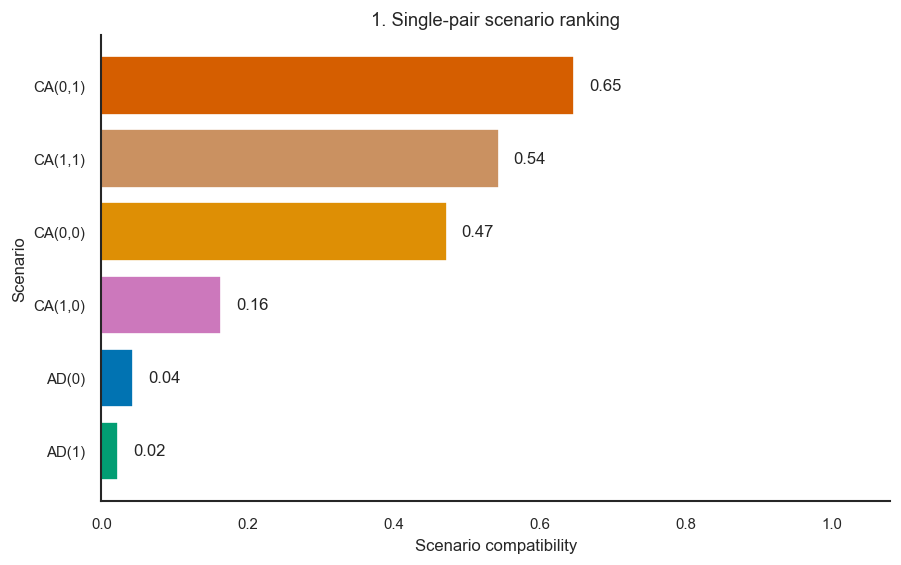

Observed time difference: 3.0 days
Observed genetic distance: 2.0 mutations
Recent-transmission target: ad(0), ca(0,0)
Summed target compatibility: 0.517


In [3]:
sample_time_difference = DEFAULT_OBSERVATION['time']
genetic_distance = DEFAULT_OBSERVATION['genetic']

model = make_model(
    mutation_process='stochastic',
    target=DEFAULT_TARGET,
)
result = model.score_pair(
    sample_time_difference=sample_time_difference,
    genetic_distance=genetic_distance,
)

compatibilities = np.array(
    [result['scenario_scores'][label]['compatibility'] for label in WINNER_SCENARIOS],
    dtype=float,
)
order = np.argsort(compatibilities)
ordered_labels = [SCENARIO_LABELS[WINNER_SCENARIOS[idx]] for idx in order]
ordered_values = compatibilities[order]
ordered_colors = [SCENARIO_COLORS[WINNER_SCENARIOS[idx]] for idx in order]

fig, ax = plt.subplots(figsize=(7.4, 4.6), constrained_layout=True)
bars = ax.barh(ordered_labels, ordered_values, color=ordered_colors)
for bar, value in zip(bars, ordered_values, strict=True):
    ax.text(value + 0.02, bar.get_y() + bar.get_height() / 2, f'{value:.2f}', va='center')

ax.set_xlabel('Scenario compatibility')
ax.set_ylabel('Scenario')
ax.set_xlim(0, 1.08)
ax.set_title('1. Single-pair scenario ranking')
finalize_axes(ax)
plt.show()

print(f'Observed time difference: {sample_time_difference:.1f} days')
print(f'Observed genetic distance: {genetic_distance:.1f} mutations')
print(f"Recent-transmission target: {', '.join(result['target_labels'])}")
print(f"Summed target compatibility: {result['target_compatibility']:.3f}")

### Supporting note: cached scorers and mutation scale

`pairwise_model(...)` is the appropriate tool when many observations are scored against the same target subset. The expected-mutation calculation is included here because it helps anchor the approximate scale of the genetic axis used later in the notebook.


In [4]:
pairwise = model.pairwise_model(target=DEFAULT_TARGET)
example_scores = pairwise(
    sample_time_difference=np.array([0.0, 2.0, 4.0]),
    genetic_distance=np.array([0.0, 1.0, 2.0]),
)
expected_mutations_4_days = model.profile.expected_mutations(4).item()

print('Cached scorer ready for repeated array-based scoring.')
print('Example batch scores:', np.round(example_scores, 3))
print(f'Expected mutations after 4 days: {expected_mutations_4_days:.3f}')

Cached scorer ready for repeated array-based scoring.
Example batch scores: [0.417 0.642 0.435]
Expected mutations after 4 days: 0.274


## 2. Representative observations along the score scale

- Purpose: Show low, medium, and high compatibility observations drawn from a simple grid so the 0 to 1 scale becomes concrete.
- How to read it: These scores refer to the recent-transmission target `ad(0) + ca(0,0)`. They quantify alignment with the target subset, not calibrated event probabilities.
- Why it matters: Similar target scores can still arise from different winning scenarios, so the scenario-level decomposition remains scientifically informative.


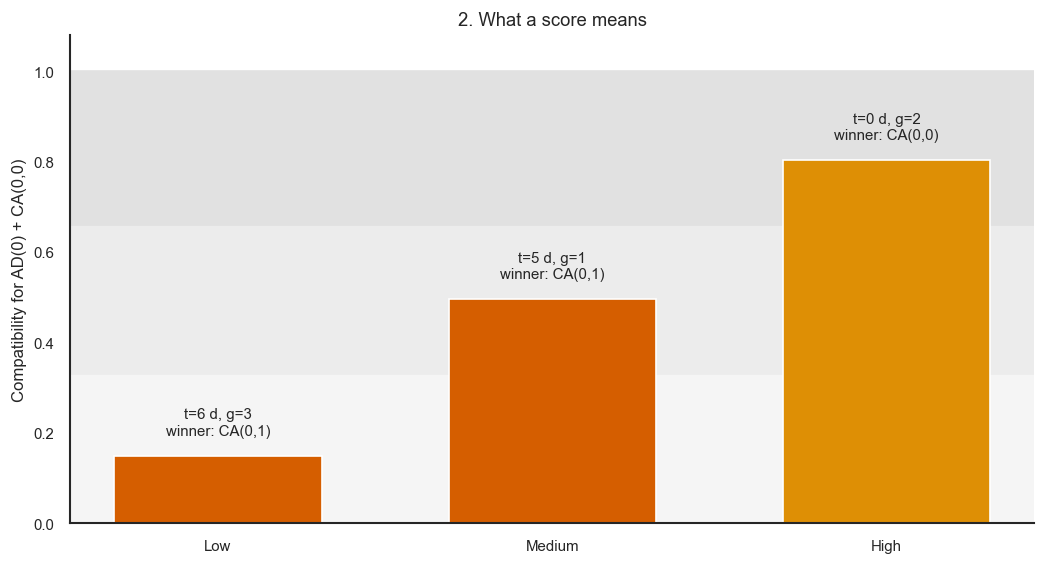

In [5]:
score_examples_model = make_model(mutation_process='stochastic', target=DEFAULT_TARGET)
representative_examples = select_representative_pairs(score_examples_model)

labels = [example['label'] for example in representative_examples]
scores = np.array([example['score'] for example in representative_examples], dtype=float)
colors = [display_color(example['winner']) for example in representative_examples]

fig, ax = plt.subplots(figsize=(8.6, 4.6), constrained_layout=True)
bars = ax.bar(labels, scores, color=colors, width=0.62)
for bar, example in zip(bars, representative_examples, strict=True):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        example['score'] + 0.04,
        (
            f"t={example['time']:.0f} d, g={example['genetic']:.0f}\n"
            f"winner: {example['winner_display']}"
        ),
        ha='center',
        va='bottom',
        fontsize=9,
    )

ax.axhspan(0.0, 0.33, color='#f5f5f5', zorder=0)
ax.axhspan(0.33, 0.66, color='#ececec', zorder=0)
ax.axhspan(0.66, 1.0, color='#e1e1e1', zorder=0)
ax.set_ylim(0, 1.08)
ax.set_ylabel(f"Compatibility for {format_target_labels(DEFAULT_TARGET)}")
ax.set_title('2. What a score means')
finalize_axes(ax)
plt.show()

## 3. Effect of target definition

- Purpose: Compare how the same observation is interpreted when the analysis target is narrowed or broadened.
- How to read it: Narrow targets answer narrower biological questions. Broader targets accumulate support across multiple compatible explanations and may therefore exceed 1.
- Why it matters: Target choice is part of the scientific question being asked, not just a technical setting.


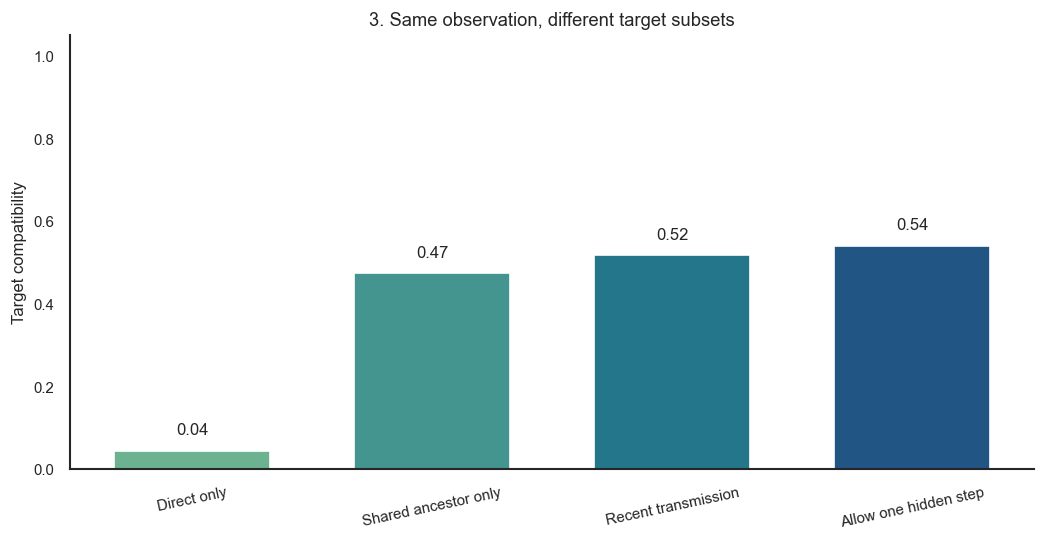

Observation: t=3.0 days, g=2.0 mutations


In [6]:
comparison_observation = DEFAULT_OBSERVATION.copy()
subset_scores = []
for _, target_labels in TARGET_COMPARISONS:
    subset_scores.append(
        float(
            model.score_target(
                comparison_observation['time'],
                comparison_observation['genetic'],
                target=target_labels,
            )
        )
    )

fig, ax = plt.subplots(figsize=(8.6, 4.4), constrained_layout=True)
bars = ax.bar(
    [name for name, _ in TARGET_COMPARISONS],
    subset_scores,
    color=sns.color_palette('crest', n_colors=len(TARGET_COMPARISONS)),
    width=0.65,
)
for bar, score in zip(bars, subset_scores, strict=True):
    ax.text(bar.get_x() + bar.get_width() / 2, score + 0.04, f'{score:.2f}', ha='center')

ax.set_ylabel('Target compatibility')
ax.set_ylim(0, max(1.05, max(subset_scores) + 0.12))
ax.set_title('3. Same observation, different target subsets')
ax.tick_params(axis='x', rotation=12)
finalize_axes(ax)
plt.show()

print(
    'Observation:',
    f"t={comparison_observation['time']:.1f} days, g={comparison_observation['genetic']:.1f} mutations",
)

## 4. Clinically interpretable toy observations

- Purpose: Summarise how EpiLink responds to a few simple observation stories that are easy to discuss in manuscript text.
- How to read it: Compatibility typically drops when timing or genetics move away from recent-transmission expectations, and either axis can weaken the joint assessment.
- Why it matters: These examples offer an intuitive bridge between the abstract score surface and realistic case-pair narratives.


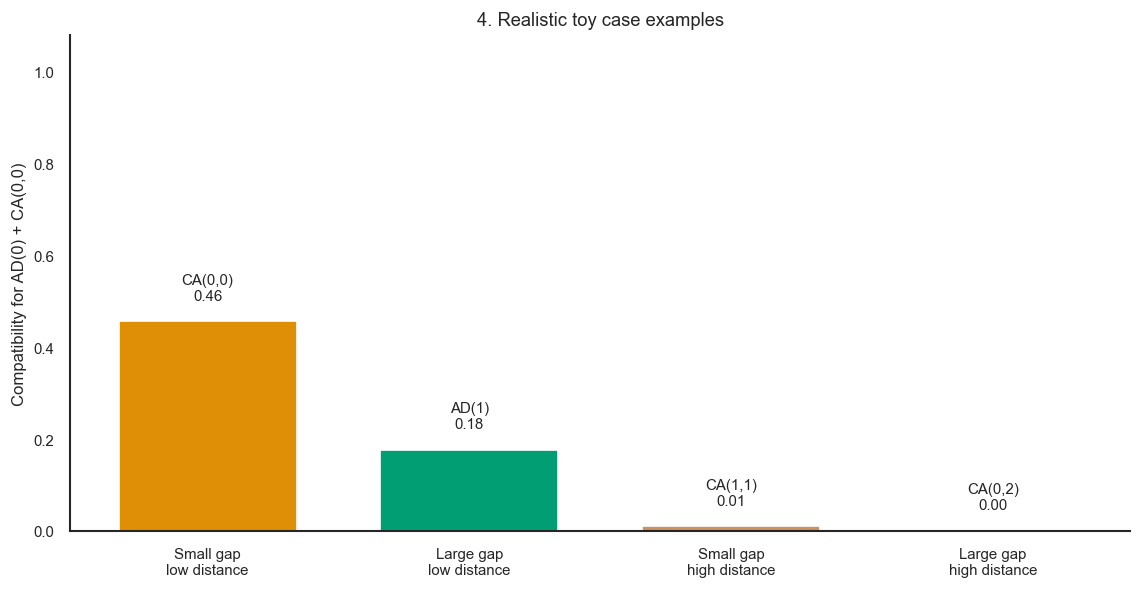

In [7]:
realistic_case_results = [
    summarize_pair(model, case['time'], case['genetic'], target=DEFAULT_TARGET)
    | {'label': case['label']}
    for case in TOY_CASES
]

scores = np.array([case['score'] for case in realistic_case_results], dtype=float)
colors = [display_color(case['winner']) for case in realistic_case_results]

fig, ax = plt.subplots(figsize=(9.4, 4.8), constrained_layout=True)
bars = ax.bar(
    [case['label'] for case in realistic_case_results],
    scores,
    color=colors,
    width=0.68,
)
for bar, case in zip(bars, realistic_case_results, strict=True):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        case['score'] + 0.04,
        f"{case['winner_display']}\n{case['score']:.2f}",
        ha='center',
        va='bottom',
        fontsize=9,
    )

ax.set_ylim(0, 1.08)
ax.set_ylabel(f"Compatibility for {format_target_labels(DEFAULT_TARGET)}")
ax.set_title('4. Realistic toy case examples')
finalize_axes(ax)
plt.show()

## 5. Score surfaces for recent transmission

- Purpose: Map compatibility for the recent-transmission target `ad(0) + ca(0,0)` over observed testing-time differences and genetic distances.
- How to read it: Brighter regions indicate observation pairs that are more compatible with recent transmission under the model.
- Why the panels differ: The stochastic mutation model introduces Poisson count noise, which broadens and can shift the region of high compatibility.


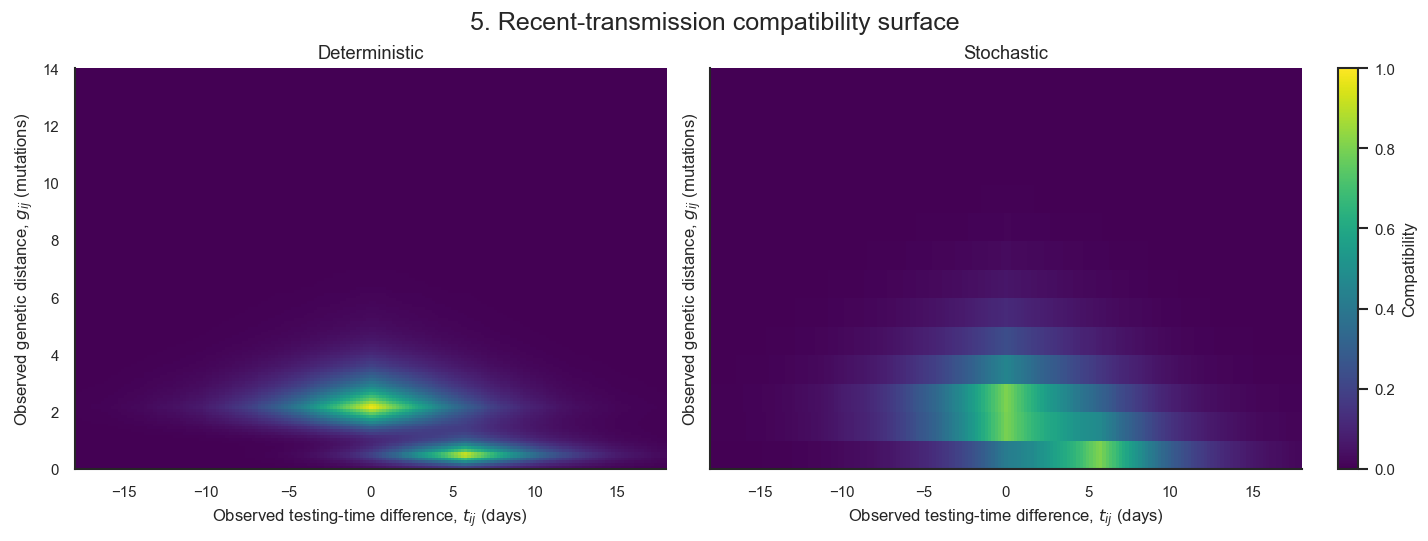

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4), sharex=True, sharey=True, constrained_layout=True)
last_image = None
for ax, (title, mutation_process) in zip(axes, MUTATION_MODELS.items(), strict=True):
    surface_model = make_model(
        mutation_process=mutation_process,
        target=DEFAULT_TARGET,
    )
    compatibility = surface_model.score_target(
        SURFACE_TIME_GRID[None, :],
        SURFACE_GENETIC_GRID[:, None],
        target=DEFAULT_TARGET,
    )
    last_image = ax.imshow(
        compatibility,
        origin='lower',
        aspect='auto',
        extent=(
            float(SURFACE_TIME_GRID.min()),
            float(SURFACE_TIME_GRID.max()),
            float(SURFACE_GENETIC_GRID.min()),
            float(SURFACE_GENETIC_GRID.max()),
        ),
        interpolation='nearest',
        cmap='viridis',
        vmin=0,
        vmax=1,
    )
    ax.set_title(title)
    ax.set_xlabel(r'Observed testing-time difference, $t_{ij}$ (days)')
    ax.set_ylabel(r'Observed genetic distance, $g_{ij}$ (mutations)')

colorbar = fig.colorbar(last_image, ax=axes, fraction=0.046, pad=0.03, label='Compatibility')
colorbar.set_ticks(np.linspace(0, 1, 6))
fig.suptitle('5. Recent-transmission compatibility surface')
finalize_axes(axes)
plt.show()

## 6. Temporal compatibility profiles

- Purpose: Isolate how timing alone separates the main recent-transmission scenarios.
- How to read it: Each curve peaks where the corresponding scenario expects the relative timing of tests to fall.
- Why it matters: Timing and genetics contribute different kinds of separation, so the temporal axis is worth inspecting on its own.


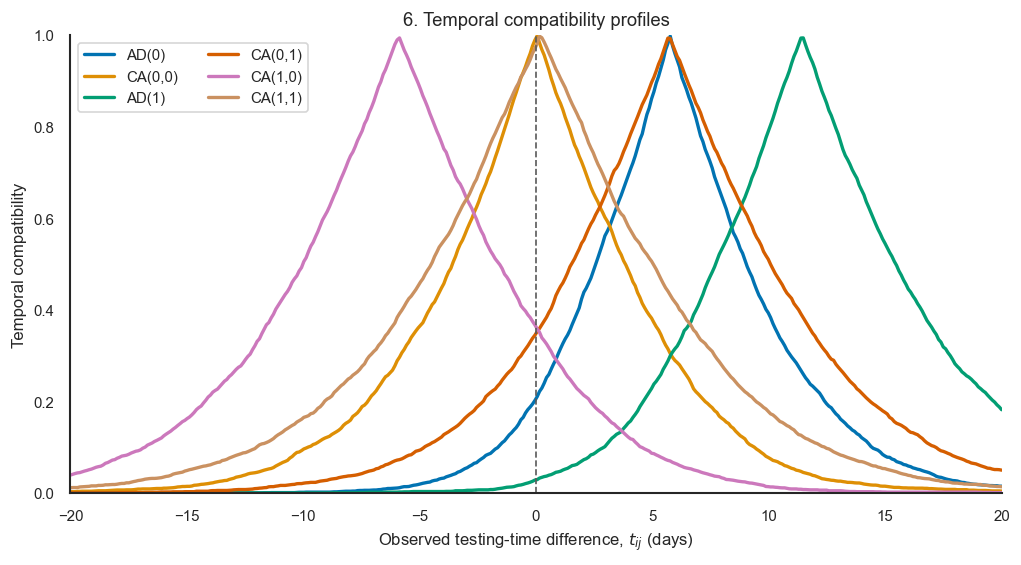

In [9]:
temporal_model = make_model(mutation_process='stochastic', target='ad(0)')
time_axis = np.linspace(-20, 20, 400)

fig, ax = plt.subplots(figsize=(8.4, 4.6), constrained_layout=True)
for label in SCENARIOS:
    curve = compatibility_curve_from_draws(time_axis, temporal_model.draws_by_scenario[label]['time_draws'])
    ax.plot(
        time_axis,
        curve,
        linewidth=2,
        color=SCENARIO_COLORS[label],
        label=SCENARIO_LABELS[label],
    )

ax.axvline(0, linewidth=1, color='0.35', linestyle='--')
ax.set_xlim(time_axis.min(), time_axis.max())
ax.set_ylim(0, 1.0)
ax.set_xlabel(r'Observed testing-time difference, $t_{ij}$ (days)')
ax.set_ylabel('Temporal compatibility')
ax.set_title('6. Temporal compatibility profiles')
ax.legend(ncol=2, loc='best')
finalize_axes(ax)
plt.show()

## 7. Genetic compatibility profiles

- Purpose: Isolate how observed mutation counts separate the same scenarios.
- How to read it: Curves closer to 1 indicate more plausible genetic distances under that scenario.
- Why the panels differ: Deterministic draws use expected mutation counts, whereas stochastic draws include Poisson variability around those expectations.


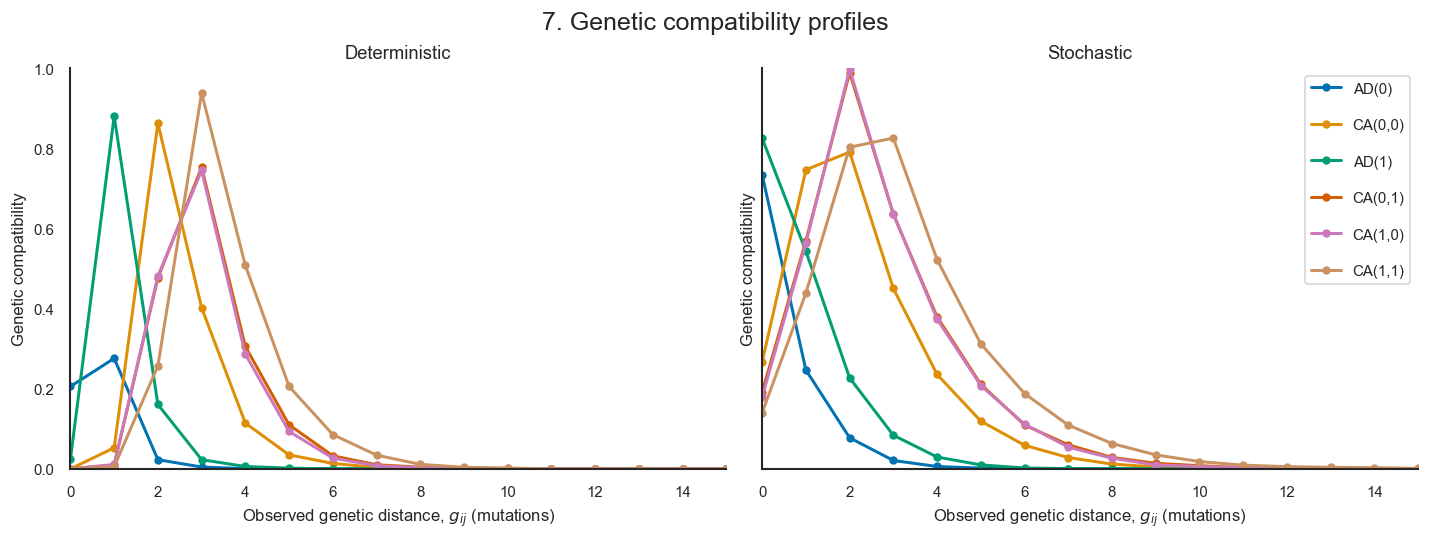

In [10]:
genetic_axis = np.arange(0, 16)

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4), sharex=True, sharey=True, constrained_layout=True)
for ax, (title, mutation_process) in zip(axes, MUTATION_MODELS.items(), strict=True):
    genetic_model = make_model(mutation_process=mutation_process, target='ad(0)')
    for label in SCENARIOS:
        curve = compatibility_curve_from_draws(genetic_axis, genetic_model.draws_by_scenario[label]['genetic_draws'])
        ax.plot(
            genetic_axis,
            curve,
            marker='o',
            markersize=4,
            linewidth=1.8,
            color=SCENARIO_COLORS[label],
            label=SCENARIO_LABELS[label],
        )
    ax.set_title(title)
    ax.set_xlabel(r'Observed genetic distance, $g_{ij}$ (mutations)')
    ax.set_ylabel('Genetic compatibility')
    ax.set_xlim(genetic_axis.min(), genetic_axis.max())
    ax.set_ylim(0, 1.0)

axes[1].legend(loc='best', labelspacing=1.5)
fig.suptitle('7. Genetic compatibility profiles')
finalize_axes(axes)
plt.show()

## 8. Most compatible latent scenario across observation space

- Purpose: Record which latent scenario has the highest compatibility at each point in the timing-genetics observation grid.
- How to read it: Each color marks the locally preferred explanation, while boundaries identify where the best explanation changes.
- Why it matters: This plot emphasises interpretability by showing where competing recent-transmission stories dominate.


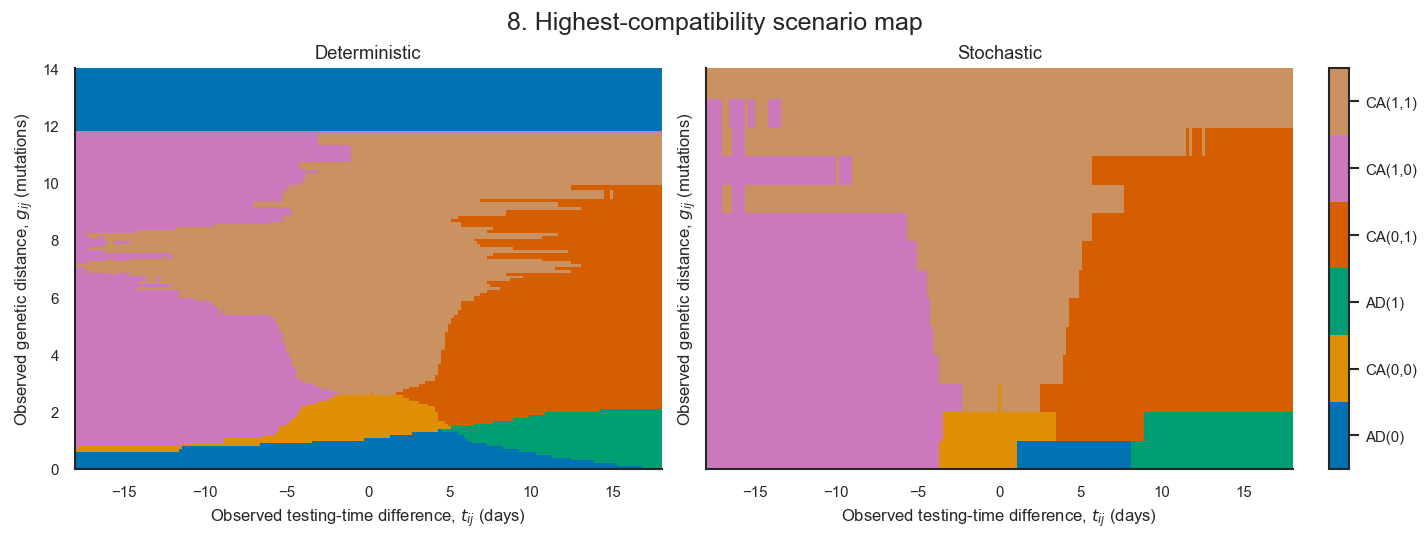

In [11]:
cmap = ListedColormap([SCENARIO_COLORS[label] for label in WINNER_SCENARIOS])

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4), sharex=True, sharey=True, constrained_layout=True)
last_image = None
for ax, (title, mutation_process) in zip(axes, MUTATION_MODELS.items(), strict=True):
    winner_model = make_model(mutation_process=mutation_process, target='ad(0)')
    winner_index = top_scenario_for_grid(winner_model, SURFACE_TIME_GRID, SURFACE_GENETIC_GRID, WINNER_SCENARIOS)
    last_image = ax.imshow(
        winner_index,
        origin='lower',
        aspect='auto',
        extent=(
            float(SURFACE_TIME_GRID.min()),
            float(SURFACE_TIME_GRID.max()),
            float(SURFACE_GENETIC_GRID.min()),
            float(SURFACE_GENETIC_GRID.max()),
        ),
        cmap=cmap,
        interpolation='nearest',
        vmin=-0.5,
        vmax=len(WINNER_SCENARIOS) - 0.5,
    )
    ax.set_title(title)
    ax.set_xlabel(r'Observed testing-time difference, $t_{ij}$ (days)')
    ax.set_ylabel(r'Observed genetic distance, $g_{ij}$ (mutations)')

colorbar = fig.colorbar(last_image, ax=axes, ticks=np.arange(len(WINNER_SCENARIOS)), fraction=0.046, pad=0.03)
colorbar.ax.set_yticklabels(WINNER_LABELS)
fig.suptitle('8. Highest-compatibility scenario map')
finalize_axes(axes)
plt.show()

## 9. Effect of allowed hidden-transmission depth

- Purpose: Show how compatibility changes as the model is allowed to include deeper hidden transmission chains.
- How to read it: Brighter regions appear when at least one scenario available at that depth can explain the observation well.
- Why it matters: Increased depth expands the latent explanation space, which can materially change what observations look plausible.


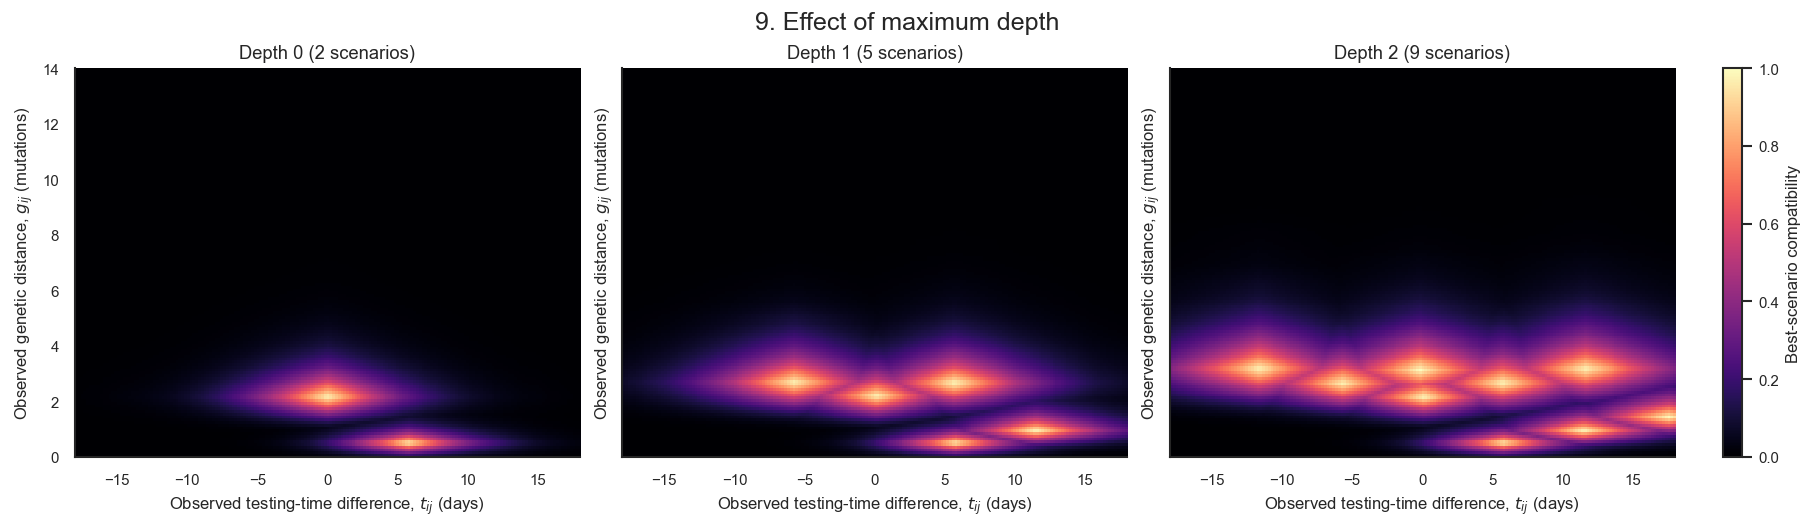

In [12]:
depths = [0, 1, 2]

fig, axes = plt.subplots(1, len(depths), figsize=(15.0, 4.3), sharex=True, sharey=True, constrained_layout=True)
last_image = None
for ax, depth in zip(axes, depths, strict=True):
    depth_model = make_model(
        mutation_process='deterministic',
        maximum_depth=depth,
        target='ad(0)',
    )
    scenario_labels = list(depth_model.scenarios_by_label)
    best_surface = best_score_for_grid(depth_model, SURFACE_TIME_GRID, SURFACE_GENETIC_GRID, scenario_labels)
    last_image = ax.imshow(
        best_surface,
        origin='lower',
        aspect='auto',
        extent=(
            float(SURFACE_TIME_GRID.min()),
            float(SURFACE_TIME_GRID.max()),
            float(SURFACE_GENETIC_GRID.min()),
            float(SURFACE_GENETIC_GRID.max()),
        ),
        interpolation='nearest',
        cmap='magma',
        vmin=0,
        vmax=1,
    )
    ax.set_title(f'Depth {depth} ({len(scenario_labels)} scenarios)')
    ax.set_xlabel(r'Observed testing-time difference, $t_{ij}$ (days)')
    ax.set_ylabel(r'Observed genetic distance, $g_{ij}$ (mutations)')

fig.colorbar(last_image, ax=axes, fraction=0.046, pad=0.03, label='Best-scenario compatibility')
fig.suptitle('9. Effect of maximum depth')
finalize_axes(axes)
plt.show()

## 10. Monte Carlo stability

- Purpose: Quantify how target scores stabilise as the number of Monte Carlo draws increases.
- How to read it: Narrower intervals indicate less Monte Carlo noise across repeated seeded runs.
- Why it matters: Borderline observations can be sensitive to coarse Monte Carlo settings, so this section provides a practical calibration check.


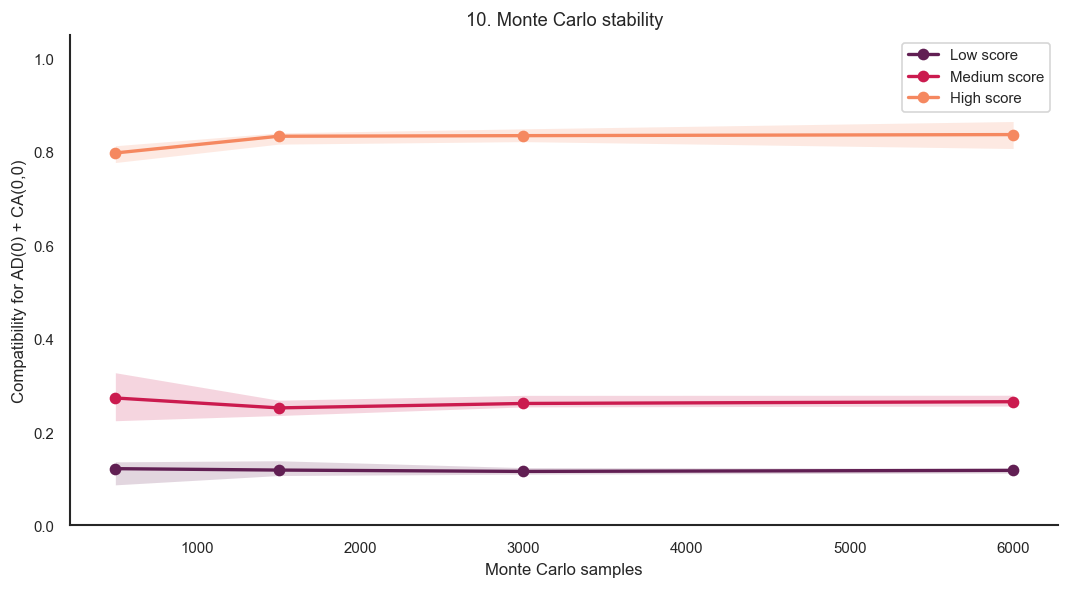

In [13]:
mc_values = np.array([500, 1_500, 3_000, 6_000])
stability_seeds = [41, 42, 43, 44]

fig, ax = plt.subplots(figsize=(8.8, 4.8), constrained_layout=True)
for example, color in zip(representative_examples, sns.color_palette('rocket', n_colors=len(representative_examples)), strict=True):
    means = []
    lows = []
    highs = []
    for mc_samples in mc_values:
        sampled_scores = []
        for seed in stability_seeds:
            stability_model = make_model(
                mutation_process='deterministic',
                seed=seed,
                mc_samples=int(mc_samples),
                target=DEFAULT_TARGET,
            )
            sampled_scores.append(
                float(
                    stability_model.score_target(
                        example['time'],
                        example['genetic'],
                        target=DEFAULT_TARGET,
                    )
                )
            )
        sampled_scores = np.asarray(sampled_scores, dtype=float)
        means.append(float(sampled_scores.mean()))
        lows.append(float(sampled_scores.min()))
        highs.append(float(sampled_scores.max()))

    means = np.asarray(means)
    lows = np.asarray(lows)
    highs = np.asarray(highs)
    ax.plot(mc_values, means, marker='o', linewidth=2, color=color, label=f"{example['label']} score")
    ax.fill_between(mc_values, lows, highs, color=color, alpha=0.18, linewidth=0)

ax.set_xlabel('Monte Carlo samples')
ax.set_ylabel(f"Compatibility for {format_target_labels(DEFAULT_TARGET)}")
ax.set_ylim(0, 1.05)
ax.set_title('10. Monte Carlo stability')
ax.legend(loc='best')
finalize_axes(ax)
plt.show()

## 11. Scenario recovery from simulated observations

- Purpose: Evaluate how often the top-ranked inferred scenario matches the true scenario used to simulate the observation pair.
- How to read it: Strong diagonal structure indicates good recovery; off-diagonal mass reveals scenarios that are difficult to distinguish.
- Why it matters: This section turns the qualitative score surfaces above into a simulation-based discrimination assessment.


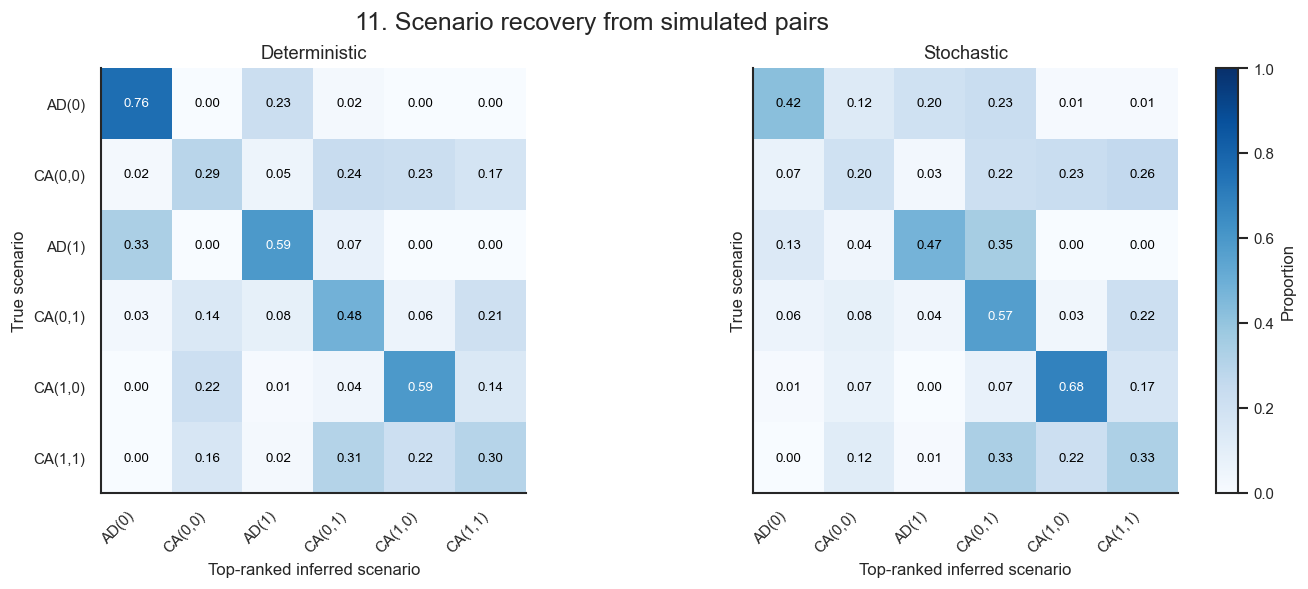

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.8), sharex=True, sharey=True, constrained_layout=True)
last_image = None
for ax, (title, mutation_process) in zip(axes, MUTATION_MODELS.items(), strict=True):
    confusion_model = make_model(mutation_process=mutation_process, target='ad(0)')
    confusion = simulate_confusion(confusion_model, WINNER_SCENARIOS, n_pairs=120)
    confusion_prop = confusion / confusion.sum(axis=1, keepdims=True)
    last_image = ax.imshow(confusion_prop, vmin=0, vmax=1, aspect='equal', cmap='Blues')
    ax.set_title(title)
    ax.set_xticks(np.arange(len(WINNER_LABELS)))
    ax.set_xticklabels(WINNER_LABELS, rotation=45, ha='right')
    ax.set_yticks(np.arange(len(WINNER_LABELS)))
    ax.set_yticklabels(WINNER_LABELS)
    ax.set_xlabel('Top-ranked inferred scenario')
    ax.set_ylabel('True scenario')
    for i in range(confusion_prop.shape[0]):
        for j in range(confusion_prop.shape[1]):
            value = confusion_prop[i, j]
            text_color = 'white' if value > 0.55 else 'black'
            ax.text(j, i, f'{value:.2f}', ha='center', va='center', fontsize=8, color=text_color)

fig.colorbar(last_image, ax=axes, fraction=0.046, pad=0.03, label='Proportion')
fig.suptitle('11. Scenario recovery from simulated pairs')
finalize_axes(axes)
plt.show()

## 12. Sensitivity to the assumed mutation rate

- Purpose: Assess robustness to misspecification of the substitution-rate assumption.
- How to read it: Stable curves indicate that scenario recovery and true-scenario compatibility are not overly dependent on the exact mutation-rate setting.
- Why it matters: Mutation-rate uncertainty is a realistic source of model misspecification in genomic epidemiology.


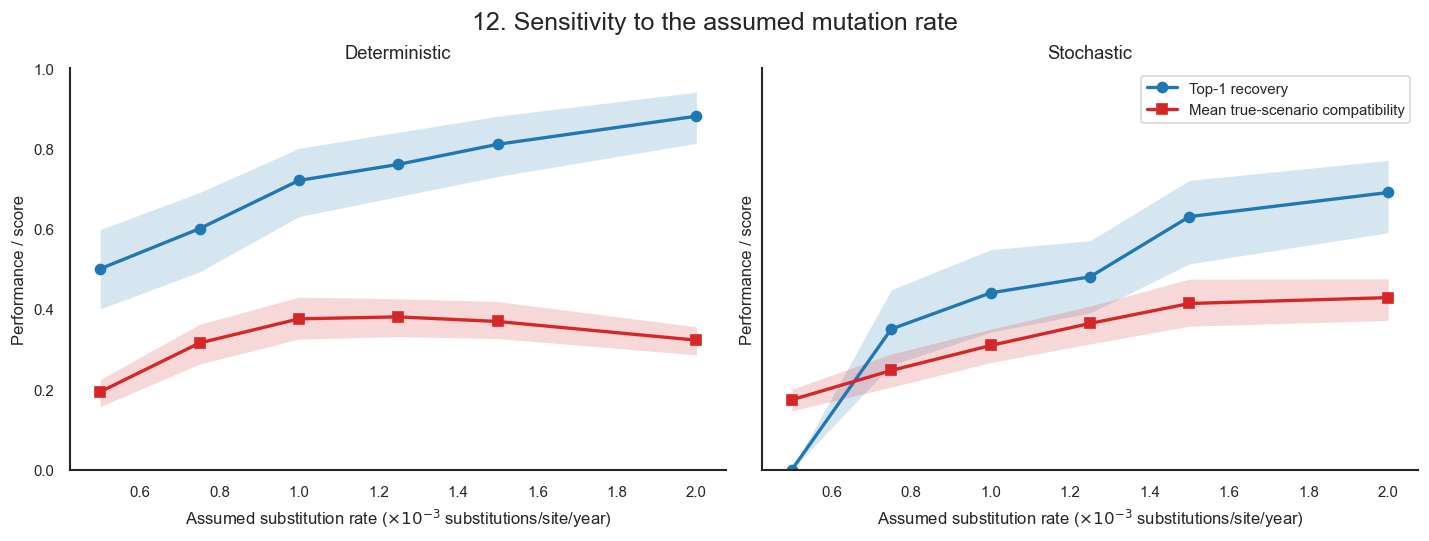

In [15]:
substitution_rates = np.array([0.5e-3, 0.75e-3, 1.0e-3, 1.25e-3, 1.5e-3, 2.0e-3])

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4), sharex=True, sharey=True, constrained_layout=True)
for ax, (title, mutation_process) in zip(axes, MUTATION_MODELS.items(), strict=True):
    (
        sensitivity_accuracy,
        sensitivity_accuracy_low,
        sensitivity_accuracy_high,
        sensitivity_truth_score,
        sensitivity_truth_score_low,
        sensitivity_truth_score_high,
    ) = sensitivity_curve(substitution_rates, mutation_process=mutation_process)

    x_values = substitution_rates * 1e3
    ax.plot(x_values, sensitivity_accuracy, marker='o', linewidth=2, color='#1f77b4', label='Top-1 recovery')
    ax.fill_between(
        x_values,
        sensitivity_accuracy_low,
        sensitivity_accuracy_high,
        color='#1f77b4',
        alpha=0.18,
        linewidth=0,
    )
    ax.plot(x_values, sensitivity_truth_score, marker='s', linewidth=2, color='#d62728', label='Mean true-scenario compatibility')
    ax.fill_between(
        x_values,
        sensitivity_truth_score_low,
        sensitivity_truth_score_high,
        color='#d62728',
        alpha=0.18,
        linewidth=0,
    )
    ax.set_title(title)
    ax.set_xlabel(r'Assumed substitution rate ($\times 10^{-3}$ substitutions/site/year)')
    ax.set_ylabel('Performance / score')
    ax.set_ylim(0, 1.0)

axes[1].legend(loc='best')
fig.suptitle('12. Sensitivity to the assumed mutation rate')
finalize_axes(axes)
plt.show()

## 13. Sensitivity to natural-history assumptions

- Purpose: Show how user-facing scores respond to alternative assumptions about testing delay and incubation timing.
- How to read it: Larger shifts indicate observations whose interpretation is more sensitive to those assumptions.
- Why it matters: This provides a concise biological sensitivity analysis for the kinds of assumptions readers often question first.


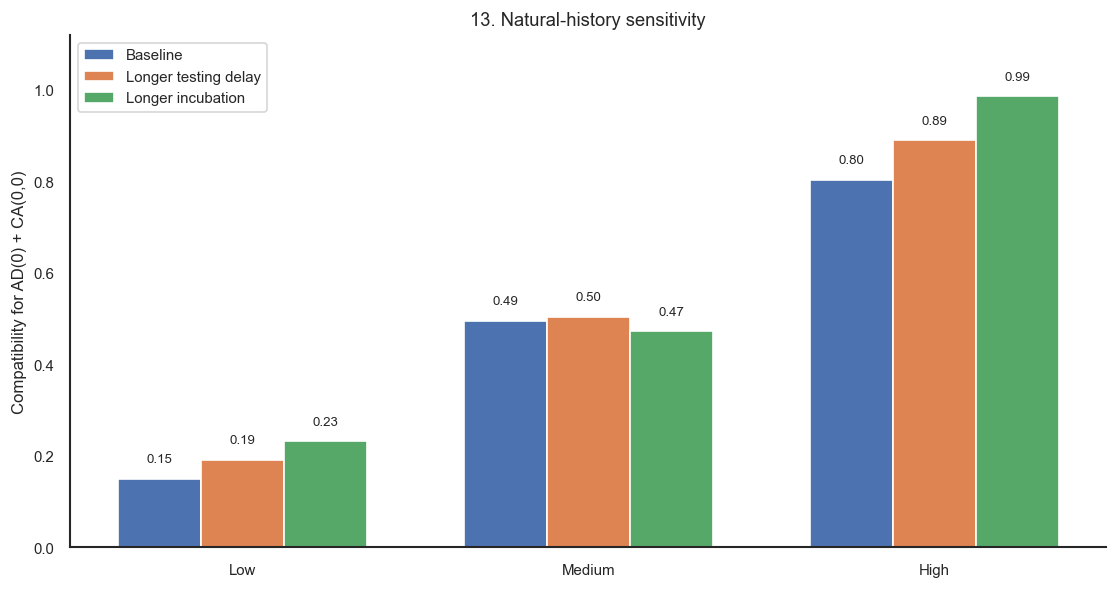

In [16]:
parameter_variants = {
    'Baseline': NaturalHistoryParameters(),
    'Longer testing delay': replace(NaturalHistoryParameters(), testing_delay_scale=1.5),
    'Longer incubation': replace(NaturalHistoryParameters(), incubation_scale=1.15),
}

x = np.arange(len(representative_examples))
width = 0.24
fig, ax = plt.subplots(figsize=(9.2, 4.8), constrained_layout=True)
for offset_idx, (variant_name, parameters) in enumerate(parameter_variants.items()):
    variant_model = make_model(
        mutation_process='stochastic',
        parameters=parameters,
        target=DEFAULT_TARGET,
    )
    values = np.array(
        [
            float(variant_model.score_target(example['time'], example['genetic'], target=DEFAULT_TARGET))
            for example in representative_examples
        ],
        dtype=float,
    )
    offset = (offset_idx - 1) * width
    ax.bar(x + offset, values, width=width, label=variant_name)
    for xpos, value in zip(x + offset, values, strict=True):
        ax.text(xpos, value + 0.03, f'{value:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([example['label'] for example in representative_examples])
ax.set_ylabel(f"Compatibility for {format_target_labels(DEFAULT_TARGET)}")
ax.set_ylim(0, 1.12)
ax.set_title('13. Natural-history sensitivity')
ax.legend(loc='best')
finalize_axes(ax)
plt.show()

## Interpretation notes

- Compatibility scores are not probabilities. They summarise how well an observation aligns with simulated draws under a scenario or target subset.
- Summed target scores can be greater than 1 when multiple scenarios are aggregated. That reflects accumulation across scenarios rather than miscalibration.
- Small differences between nearby scenarios are often less important than the broader pattern of which scenario families remain plausible.
- Low scores do not prove that a pair is unrelated; they indicate poor alignment with the chosen model assumptions and target set.
- Target choice is scientific, not cosmetic. `['ad(0)']` answers a narrower question than `['ad(0)', 'ca(0,0)']`.
- Mutation rate, testing delay, incubation timing, hidden depth, and Monte Carlo settings can all move the score scale.


## Summary for manuscript readers

- EpiLink is most supportive of recent transmission when both testing-time difference and genetic distance lie near the centre of a scenario's simulated draws.
- Timing and genetic evidence separate scenarios in complementary ways, so both axes matter for interpretation.
- Allowing deeper hidden transmission paths broadens the region of observation space that can be explained well.
- Stochastic mutation modelling broadens compatibility surfaces and makes scenario overlap more visible than purely deterministic expectations.
- The overall qualitative behaviour is stable, but borderline observations are more sensitive to Monte Carlo resolution and biological assumptions.
- For end-to-end synthetic outbreak generation, pairwise table construction, and worked simulation examples, see `examples/simulation.ipynb`.


## Session information

This final cell is a lightweight provenance record that can be useful when archiving the notebook alongside manuscript materials.


In [17]:
{
    'python': supplement_metadata['python'],
    'platform': supplement_metadata['platform'],
    'numpy': supplement_metadata['numpy'],
    'matplotlib': supplement_metadata['matplotlib'],
    'seaborn': supplement_metadata['seaborn'],
    'epilink': supplement_metadata['epilink'],
    'seed': supplement_metadata['seed'],
    'maximum_depth': supplement_metadata['maximum_depth'],
    'mc_samples': supplement_metadata['mc_samples'],
}


{'python': '3.14.3',
 'platform': 'macOS-26.3.1-arm64-arm-64bit-Mach-O',
 'numpy': '2.4.3',
 'matplotlib': '3.10.8',
 'seaborn': '0.13.2',
 'epilink': '0.1.2',
 'seed': 2026,
 'maximum_depth': 2,
 'mc_samples': 6000}